In [7]:
import numpy as np
from scipy.linalg import block_diag

np.set_printoptions(legacy='1.13',linewidth=np.inf)

import matplotlib.pyplot as plt

In [8]:
#test bath degen
A = np.array([[3,0],[0,3]]) # Energy_R = 0.5 space
B= np.array([[2,0,0],[0,2,0],[0,0,2]]) # Energy_R = 1.5 space
C = [[3]] # Energy_R = 2.5 space
P = np.zeros((2,0))

#Quantum system(Stochastic matrix, not a density operator)
statevec1 = np.array([0.2,0.7,0.1])
statevec2 = np.array([0.5,0.3,0.2])
statevec3 = np.array([0.3,0,0.7])


#Quantum system(density operator,non-normalized)
S1 = np.outer(statevec1,statevec1)
S2 = np.outer(statevec2,statevec2)
#S3 = np.outer(np.array([0.3,0.0,0.7]),np.array([0.3,0.0,0.7]))

In [9]:
#Case that using density operator
#Tot_Energy: 0.5
E051 = np.reshape(np.tensordot(A,S1,axes=0),(6,6))
#Tot_Energy: 1.5
E151 = np.reshape(np.tensordot(B,S1,axes=0),(9,9))
E152 = np.reshape(np.tensordot(A,S1,axes=0),(6,6))
#Tot_Energy: 2.5
E251 = np.reshape(np.tensordot(B,S2,axes=0),(9,9))
E252 = np.reshape(np.tensordot(C,S1,axes=0),(3,3))
#

In [10]:
#density operator case
matrix = block_diag(E051,E151,E152,E251,E252)

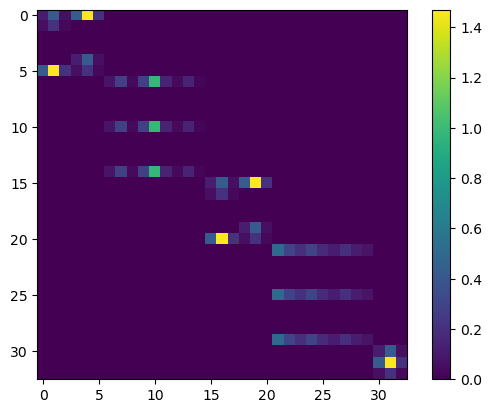

In [11]:
plt.imshow(matrix, cmap='viridis')
plt.colorbar()

# 수직선
#plt.vlines(x=[5, 14], ymin=0, ymax=matrix.shape[0], colors='red',linewidth=0.5)

# 수평선
#plt.hlines(y=[5, 14], xmin=0, xmax=matrix.shape[1], colors='red',linewidth=0.5)

plt.show()

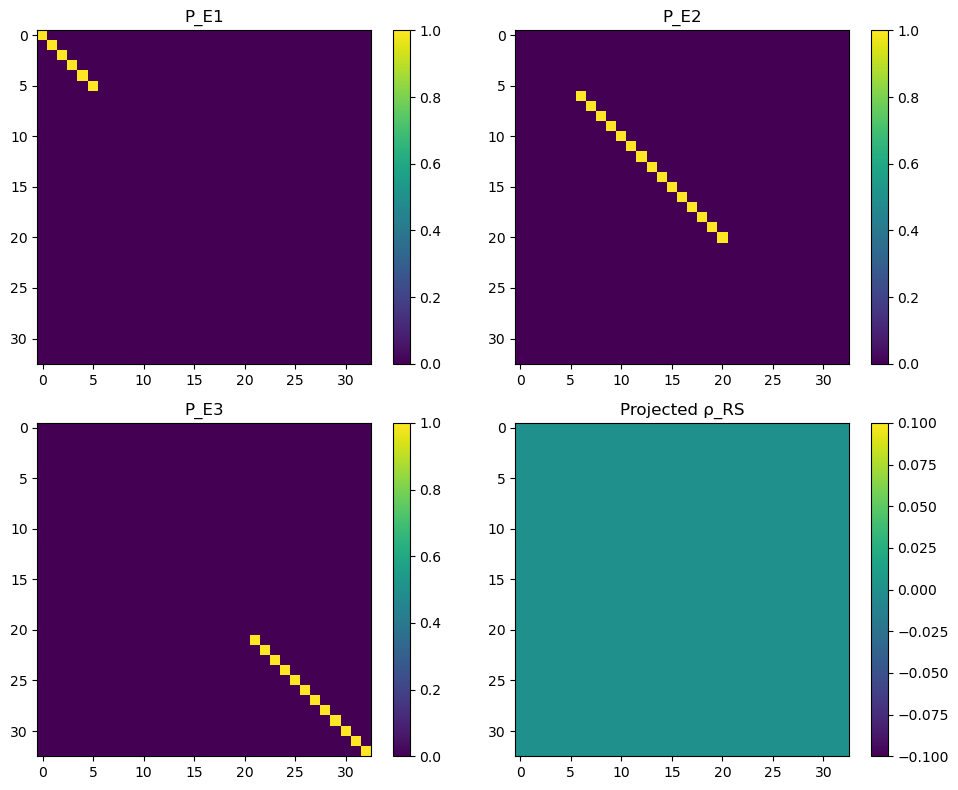

In [12]:
def energy_projector(total_dim, energy_indices):
    """
    Creates a projector onto energy subspaces

    Parameters:
    total_dim: Total dimension of the system
    energy_indices: List of indices corresponding to the energy subspace

    Returns:
    Projector matrix P_E
    """
    projector = np.zeros((total_dim, total_dim))
    for i in energy_indices:
        projector[i, i] = 1.0
    return projector

# Total dimension of your system
#total_dim = AA.shape[0] + BB.shape[0] + CC.shape[0]# (6+9+3)
total_dim = matrix.shape[0]

# Define energy levels based on your block structure
# For example, let's say:
# E=1 corresponds to the first block (AA)
# E=2 corresponds to the second block (BB)
# E=3 corresponds to the third block (CC)

# Indices for each energy subspace
E_S1_indices = (range(0,6),range(6,15),range(21,30))
E_S2_indices = (range(15,21),range(30,33))

E0_range = range(0,6)
E1_range = range(6,21)
E2_range = range(21,33)

# Create projectors
P_E1 = energy_projector(total_dim, E0_range)
P_E2 = energy_projector(total_dim, E1_range)
P_E3 = energy_projector(total_dim, E2_range)

#delta projector : change the index number to select the range
E_S1_projector = energy_projector(total_dim, E_S1_indices[1])
E_S2_projector = energy_projector(total_dim, E_S2_indices[0])

# Now we can implement equation (1.3)
# Let's create a sample density matrix rho_RS
#rho_RS = matrix[6:15][:,6:15]
rho_RS=matrix

# Projecting the state according to eq. (1.3)
# For example, if we want to get the component with E and E+Δ where E=1 and Δ=1
P_E_rho_P_E_plus_delta = P_E1 @ rho_RS @ E_S1_projector

# To get the complete decomposition, we need to sum over all E and Δ
# For example:
#projected_rho = np.zeros((total_dim, total_dim), dtype=complex)
#for P_E, P_E_plus_delta in [(P_E1, P_E1), (P_E1, P_E2), (P_E2, P_E1), (P_E2, P_E2),
#                            (P_E1, P_E3), (P_E3, P_E1), (P_E2, P_E3), (P_E3, P_E2),
#                            (P_E3, P_E3)]:
#    projected_rho += P_E @ rho_RS @ P_E_plus_delta

# Visualize the projector
plt.figure(figsize=(10, 8))
plt.subplot(221)
plt.imshow(P_E1, cmap='viridis')
plt.title('P_E1')
plt.colorbar()

plt.subplot(222)
plt.imshow(P_E2, cmap='viridis')
plt.title('P_E2')
plt.colorbar()

plt.subplot(223)
plt.imshow(P_E3, cmap='viridis')
plt.title('P_E3')
plt.colorbar()

plt.subplot(224)
plt.imshow(np.abs(P_E_rho_P_E_plus_delta), cmap='viridis')
plt.title('Projected ρ_RS')
plt.colorbar()


#plt.subplot(224)
#plt.imshow(np.abs(projected_rho), cmap='viridis')
#plt.title('Projected ρ_RS')
#plt.colorbar()

plt.tight_layout()
plt.show()